### References

https://github.com/gabrielziegler3/xgboost-multiclass-multilabel/blob/master/xgboost-multiclass/multiclass-frog-classification.ipynb


In [85]:
import os

import mlflow
import mlflow.xgboost
import mlflow.sklearn

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display
from sklearn.feature_selection import mutual_info_regression
import plotly

from sklearn.model_selection import train_test_split
from xgboost.sklearn import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import recall_score, f1_score, precision_score, precision_recall_fscore_support
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.datasets import make_classification

import matplotlib.pyplot as plt


In [86]:
not_use_cols = ['date']
attr_cols = ['open', 'high', 'low', 'close', 'volume', 'average', 'barCount']
hist_5_cols = ['h5s_high_max',  'h5s_low_min',  'h5s_barCount_sum',  'h5s_volume_sum', 'h5s_average_avg']
hist_10_cols= ['h10s_high_max', 'h10s_low_min', 'h10s_barCount_sum', 'h10s_volume_sum','h10s_average_avg']
hist_15_cols= ['h15s_high_max', 'h15s_low_min', 'h15s_barCount_sum', 'h15s_volume_sum','h15s_average_avg']
pred_cols= [ 'f5s_average', 'f5s_10c_arrow', 'f5s_15c_arrow', 'f5s_20c_arrow', 'f5s_20c_arrow', 'f5s_25c_arrow']
x_cols = [ ]

x_cols += attr_cols + hist_5_cols + hist_10_cols + hist_15_cols
y_cols = [pred_cols[2]]
bin_counts = 3

data_file = "./TSLA-Stocks/All.csv"

In [87]:
mlflow.set_experiment("vol-xgboost")
mlflow.xgboost.autolog()

In [88]:
plt.style.use("seaborn-whitegrid")
plt.rc("figure", autolayout=True)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)

In [89]:
def load_data():
    data = pd.read_csv(data_file, low_memory=False)
    msg = f"raw:  {data.shape}"

    all_cols = x_cols + y_cols
    data = data [ all_cols ]
    data = data.dropna()
    msg += f" na {data.shape}"

    print (" size", msg)
    mlflow.log_param(" size", msg)
    # data = data.head(10000)
    return data

# Code

## load data / split data

In [90]:
%%time
data = load_data()
X = data[x_cols]
y = data [y_cols]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
msg = f"Train {X_train.shape},{y_train.shape}, Test {X_test.shape}, {y_test.shape}"
print (msg)

 size raw:  (3538806, 30) na (3489409, 23)
Train (2442586, 22),(2442586, 1), Test (1046823, 22), (1046823, 1)
CPU times: user 12.8 s, sys: 2.52 s, total: 15.3 s
Wall time: 15.3 s


## Scale Data

In [91]:
# Standard Scaled X Prediction
scalar = StandardScaler()
scalar.fit(X_train)
X_train = pd.DataFrame(scalar.transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(scalar.transform(X_test), columns=X_test.columns)
#x_train = scalar.transform(x_train)
#x_test = scalar.transform(x_test)


In [92]:
# XGB Parameters

#  https://xgboost.readthedocs.io/en/stable/parameter.html
params2 = {
        'objective': 'multi:softprob',
        'enable_categorical': False,
        'eval_metric': 'merror'  # mlogloss or merror
}
params = {
        'copy_X': True,
        'fit_intercept': False,
        'normalize': True,
        '_kfold': 2,
        # 'objective': 'validation:accuracy',
        'objective': 'multi:softprob',
        'num_class': bin_counts,
        # 'objective': 'binary:logistic',
        'enable_categorical': False,
        '_tuning_objective_metric': 'validation:f1',
        'eval_metric': 'auc',
        # 'tree_method': 'gpu_hist',
        # 'eval_metric': 'accuracy,f1',
        # 'eval_metric':'merror',
        # 'eval_metric': 'accuracy,f1X',
        # Muthu params
        #'subsample': 0.75,  # Setting it to 0.5 means that XGBoost would randomly sample half of the training data prior to growing trees. and this will prevent overfitting.
        'gamma': 0.001,  # Minimum loss reduction required to make a further partition on a leaf node of the tree. The larger gamma is, the more conservative the algorithm will be
        'alpha': 0.0,  # L1 regularization is Lasso Regression wich adds “squared magnitude” of coefficient as penalty term to the loss functi
        'lambda': 1.0,  # L2 regularization is Ridge Regression which adds “absolute value of magnitude” of coefficient as penalty term to the loss function.
        'eta': 0.03,  # Step size shrinkage used in update to prevents overfitting
        'min_child_weight': 0.05,  # Minimum sum of instance weight (hessian) needed in a child the building process will give up further partitioning.
        # not too sure.
        'max_depth': 10,  # Maximum tree depth for base learners.
        # 'early_stopping_rounds': 50,  # don't over fit
        'num_round': 100,  # num_boost_round == num_boost_round
        'use_label_encoder': False # UserWarning: The use of label encoder in XGBClassifier is deprecated...
    }

In [93]:
# fig, ax = plt.subplots()
#sns.set(rc={'figure.figsize': (12, 9)})
# x_train.plot.hist(alpha=0.5)
#ax = x_train.hist()
# x_train.hist()
# fig = ax.get_figure()
#ax.figure.savefig('TrainingHistogram.png')
#mlflow.log_figure(fig, "TrainingHistogram.png")
# plt.show()
#data2 = data [x_cols + y_cols ]
#data2.plot.hist();
#corr = data2.corr()
#corr.style.background_gradient(cmap='coolwarm').set_precision(2)
#plt.show()
#print(corr)
#sns.set(rc={'figure.figsize':(66,48)})
#sns.heatmap(corr, annot=True)


## mlflow logging

### [reference page](https://learn.microsoft.com/en-us/azure/machine-learning/how-to-log-view-metrics?tabs=interactive)

In [94]:
#mlflow.set_experiment("xgb-binary-" + y_cols[0])
mlflow.xgboost.autolog()
#mlflow.start_run()

In [95]:
#df = data.head(1000)
#plt.matshow(df.corr())
#corr = df.corr()
#corr.style.background_gradient(cmap='coolwarm').set_precision(2)
#plt.show()
#print(corr)
#sns.heatmap(corr, annot=True)


In [96]:
xgb = XGBClassifier(**params2)
print(xgb.get_xgb_params())
mlflow.log_param('xgb_params', xgb.get_xgb_params())


{'objective': 'multi:softprob', 'base_score': None, 'booster': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'gamma': None, 'gpu_id': None, 'interaction_constraints': None, 'learning_rate': None, 'max_delta_step': None, 'max_depth': None, 'min_child_weight': None, 'monotone_constraints': None, 'n_jobs': None, 'num_parallel_tree': None, 'predictor': None, 'random_state': None, 'reg_alpha': None, 'reg_lambda': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None, 'eval_metric': 'merror'}


## Create XGB Model

In [97]:
%%time
# Train model & predict
xgb.fit(X_train, y_train)


/Users/Muthu/Development/OptionList4/lib/python3.9/site-packages/xgboost/sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
/Users/Muthu/Development/OptionList4/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:98: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/Muthu/Development/OptionList4/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:133: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for

CPU times: user 46min 6s, sys: 1min 16s, total: 47min 22s
Wall time: 5min 42s


XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, enable_categorical=False,
              eval_metric='merror', gamma=0, gpu_id=-1, importance_type=None,
              interaction_constraints='', learning_rate=0.300000012,
              max_delta_step=0, max_depth=6, min_child_weight=1, missing=nan,
              monotone_constraints='()', n_estimators=100, n_jobs=10,
              num_parallel_tree=1, objective='multi:softprob', predictor='auto',
              random_state=0, reg_alpha=0, reg_lambda=1, scale_pos_weight=None,
              subsample=1, tree_method='exact', validate_parameters=1,
              verbosity=None)

In [98]:
y_pred = xgb.predict(X_test)

In [99]:
#average setting, one of [None, 'micro', 'macro', 'weighted']
precision, recall, f1, y_true = precision_recall_fscore_support(y_test, y_pred, average='weighted')

ps = precision_score(y_test, y_pred, average='weighted')
rs = recall_score(y_test, y_pred, average='weighted')
ac = accuracy_score(y_test, y_pred)

ps_str = f"{ps:.3f}"
rs_str = f"{rs:.3f}"
ac_str = f"{ac:.3f}"

print(f"accuracy: {round(ac, 3)} precision {round(ps, 3)} recall {round(rs, 3)}")
mlflow.log_metrics({'accuracy': round(ac, 3), 'precision': round(ps, 3), 'recall': round(rs, 3)})


accuracy: 0.903 precision 0.89 recall 0.903


In [100]:
def plot_confusion_matrix(cm, classes, normalized=True, cmap='bone', fmt='.3g'):
    #plt.figure(figsize=[7, 6])
    plt.figure(figsize=[14, 12])
    norm_cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    print(cm)
    print(norm_cm)

    arr = [["-"]*len(cm)]*len(cm)
    for j in range(len(cm)):
        for i in range(len(cm[j])):
            arr[j][i] =  f"{cm[j][i]:,d}\n{norm_cm[j][i]:.3f}%"
            print(cm[j][i], arr[j][i])
    print(arr)
    sns.heatmap(norm_cm, annot=arr, annot_kws={'size': 15}, fmt='s', normalize=True)

In [101]:
cm = confusion_matrix(y_test, y_pred, labels=[-1,0,1])
norm_cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

print (cm)


[[  4870  49154    126]
 [  1282 936672    641]
 [   679  49830   3569]]


<Figure size 1008x864 with 0 Axes>

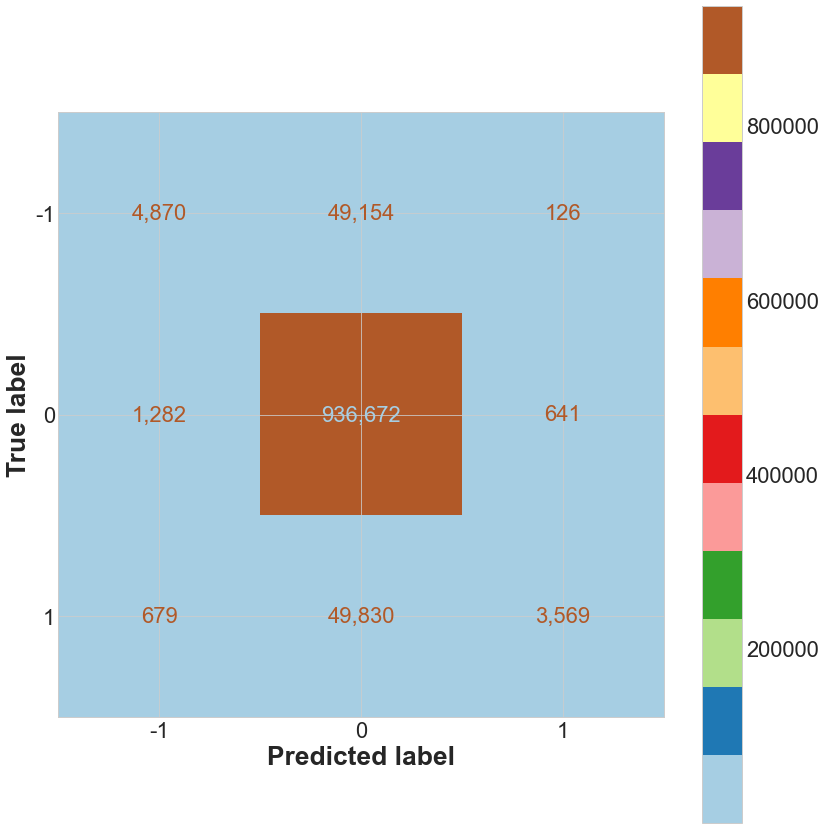

In [102]:
plt.figure(figsize=[14, 12])

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=[-1, 0, 1])
disp.plot(cmap=plt.cm.Paired,  values_format=',')
fig = disp.ax_.get_figure()
fig.set_figwidth(12)
fig.set_figheight(12)

font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : 22}

# print (plt.rcParams.keys())
plt.rcParams.update({'font.size': 22})
plt.show()
mlflow.log_figure(fig, 'confusion_matrix.png')


In [103]:
cm_json = {}
cm_json.update({"Confusion_Matrix": cm})
mlflow.log_param("confusion_matrix.json", cm_json)
print(cm_json)

{'Confusion_Matrix': array([[  4870,  49154,    126],
       [  1282, 936672,    641],
       [   679,  49830,   3569]])}


In [104]:
# from mlflow.models.signature import infer_signature
# signature = infer_signature(x_train, xgb.predict(xgb.DMatrix(data=x_train, label=y_train)))
# mlflow.xgboost.log_model(xgb, "model") #, signature=signature)""
#fig, ax = plt.subplots()
#sns.set(rc = {'figure.figsize':(12,9)})
#ns.heatmap(cm, annot=True, cmap="YlGnBu",fmt='d')
#fig.savefig("ConfusionMatrix.png")
#mlflow.log_figure(fig, "ConfusionMatrix.png")
#plt.show()

#sns.heatmap(cm_pct, annot=True, cmap="YlGnBu", fmt=".3f")
#fig.savefig("ConfusionMatrixPct.png")
#mlflow.log_figure(fig, "ConfusionMatrixPct.png")
#plt.show()


# feature_importances = pd.DataFrame(xgb.feature_importances_,index=x_train.columns.tolist(),columns=['importance'])
# feature_importances.sort_values('importance', ascending=False)


In [110]:
feature_importances = pd.DataFrame(xgb.feature_importances_,index=X_train.columns.tolist(),columns=['importance'])
vals = feature_importances.sort_values('importance', ascending=False)
mlflow.log_param("feature_importance", vals.to_string)
vals

,importance
h5s_volume_sum,0.305645
volume,0.140833
average,0.088140
h5s_high_max,0.086194
h5s_low_min,0.077062
high,0.065991
low,0.059551
h5s_barCount_sum,0.054471
close,0.052829
barCount,0.038332


In [106]:
# plot
#from matplotlib import pyplot
#pyplot.bar(range(len(xgb.feature_importances_)), xgb.feature_importances_)
#pyplot.show()

In [107]:
mlflow.end_run()

# ToDo

* add history: h1, h2, h3, h4, h5.  There seems to be no value for >5
* filter time to 9:45 - 15:45
* remove non-full days
* add vix index
* move data to MySQL

DONE:

* Create multiple arrow buckets ('f5s_10c_arrow', 'f5s_20c_arrow') += 'f5s_15c_arrow', 'f5s_25c_arrow', 'f5s_30c_arrow'